# Tutorial: 3D Poisson with `volumential`

This notebook mirrors the structure of the 2D Poisson tutorial, but runs a true 3D manufactured Poisson solve on a box using `volumential` volume FMM.

Compared to the 2D tutorial, this one emphasizes:

- larger 3D workloads,
- uniform co-refinement in 3D,
- richer visualization (orthogonal slices, 3D point-cloud error, interactive isosurfaces).


## Roadmap

1. **Problem definition**: manufactured exact solution and forcing `f = -\Delta u`.
2. **Infrastructure setup**: OpenCL context + near-field table cache.
3. **Solver module**: reusable `run_poisson3d_case(...)`.
4. **Single-resolution walkthrough**: inspect diagnostics and plots.
5. **Uniform co-refinement study**: increase grid levels and quantify error/cost trends.
6. **Interactive 3D visualization**: isosurfaces for potential and error hot spots.
7. **Takeaways**: what to tune next for your own runs.


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import os
import time

import numpy as np
import matplotlib.pyplot as plt

import pyopencl as cl
import pyopencl.array  # noqa: F401

from pytools.obj_array import new_1d as obj_array_1d

import volumential.meshgen as mg
from volumential.meshgen import build_geometry_info
from volumential.table_manager import NearFieldInteractionTableManager
from volumential.nearfield_potential_table import DuffyBuildConfig
from volumential.expansion_wrangler_fpnd import (
    FPNDExpansionWrangler,
    FPNDTreeIndependentDataForWrangler,
)
from volumential.volume_fmm import drive_volume_fmm, interpolate_volume_potential

from sumpy.expansion import DefaultExpansionFactory
from sumpy.kernel import LaplaceKernel

plt.style.use('seaborn-v0_8-whitegrid')


/home/xywei/Work/fmm/volumential-ipa-run/volumential/__init__.py:41: UserWarning: pytools.persistent_dict 'volumential-code-cache-v0-2017.1a0': enabling safe_sync as default. This provides strong protection against data loss, but can be unnecessarily expensive for use cases such as caches.Pass 'safe_sync=False' if occasional data loss is tolerable. Pass 'safe_sync=True' to suppress this warning.
  code_cache = WriteOncePersistentDict("volumential-code-cache-v0-"+VERSION_TEXT)


## 1) Problem Definition

We use a smooth manufactured exact solution made of two shifted Gaussian bumps:

- `u_exact(x, y, z) = g1 + c * g2`
- `f(x, y, z) = -\Delta u_exact`

This gives exact values everywhere for robust error checks.


In [2]:
smoke_mode = os.environ.get('VOLUMENTIAL_EXAMPLE_SMOKE', '').lower() in {'1', 'true', 'yes'}

dim = 3
bbox_a, bbox_b = -0.5, 0.5
table_root_extent = 2.0

if smoke_mode:
    q_order = 3
    default_nlevels = 2
    fmm_order = 10
    regular_quad_order = 10
    radial_quad_order = 35
    slice_side = 72
    volume_side = 20
else:
    q_order = 5
    default_nlevels = 4
    fmm_order = 18
    regular_quad_order = 16
    radial_quad_order = 80
    slice_side = 170
    volume_side = 44

table_filename = (
    'nft_poisson3d_notebook_smoke.sqlite' if smoke_mode
    else 'nft_poisson3d_notebook.sqlite'
)

artifact_dir = Path('poisson3d_notebook_output')
artifact_dir.mkdir(parents=True, exist_ok=True)

alpha_1 = 120.0
alpha_2 = 90.0
coeff_2 = -0.65

def _gaussian(alpha, dx, dy, dz):
    r2 = dx * dx + dy * dy + dz * dz
    return np.exp(-alpha * r2), r2

def _minus_laplacian_gaussian(alpha, r2):
    return (2 * dim * alpha - 4 * alpha * alpha * r2)

def u_exact(x, y, z):
    g1, _ = _gaussian(alpha_1, x + 0.08, y - 0.06, z + 0.05)
    g2, _ = _gaussian(alpha_2, x - 0.09, y + 0.07, z - 0.08)
    return g1 + coeff_2 * g2

def rhs_f(x, y, z):
    g1, r1 = _gaussian(alpha_1, x + 0.08, y - 0.06, z + 0.05)
    g2, r2 = _gaussian(alpha_2, x - 0.09, y + 0.07, z - 0.08)
    return _minus_laplacian_gaussian(alpha_1, r1) * g1 + coeff_2 * _minus_laplacian_gaussian(alpha_2, r2) * g2

print('smoke_mode:', smoke_mode)
print('q_order:', q_order, '| default_nlevels:', default_nlevels, '| fmm_order:', fmm_order)
print('table cache:', table_filename)
print('artifact dir:', artifact_dir)


smoke_mode: False
q_order: 5 | default_nlevels: 4 | fmm_order: 18
table cache: nft_poisson3d_notebook.sqlite
artifact dir: poisson3d_notebook_output


## 2) Infrastructure Setup

Build OpenCL context and near-field table once so multiple runs can reuse cache.


In [3]:
ctx = cl.create_some_context()
queue = cl.CommandQueue(ctx)

tm = NearFieldInteractionTableManager(
    table_filename,
    root_extent=table_root_extent,
    queue=queue,
)
build_config = DuffyBuildConfig(
    radial_rule='tanh-sinh-fast',
    regular_quad_order=regular_quad_order,
    radial_quad_order=radial_quad_order,
)

nftable, _ = tm.get_table(
    dim,
    'Laplace',
    q_order,
    force_recompute=False,
    queue=queue,
    build_config=build_config,
)

print('near-field table ready:', table_filename)


SYCL CPU RT Warning: Unknown host CPU.


near-field table ready: nft_poisson3d_notebook.sqlite


## 3) Solver Module

`run_poisson3d_case(...)` executes one full solve and returns diagnostics.

For each run it:

1. Builds a 3D tensor-product quadrature mesh.
2. Evaluates source values from `f = -\Delta u_exact`.
3. Builds a mesh-aligned source-only tree (`targets=None`) from mesh boxtree geometry so source nodes stay consistent with box extents.
4. Builds boxtree traversal and FMM wrangler.
5. Executes volume FMM and compares against the exact field at source quadrature nodes.

Using mesh-aligned coincident trees avoids unnecessary source-to-target interpolation and removes root-extent drift that otherwise degrades 3D convergence.


In [4]:
def _to_obj_array(arrays):
    return obj_array_1d([cl.array.to_device(queue, np.ascontiguousarray(a)) for a in arrays])

def run_poisson3d_case(*, nlevels, fmm_order_case=None, return_fields=False):
    if fmm_order_case is None:
        fmm_order_case = fmm_order

    mesh = mg.MeshGen3D(q_order, nlevels, bbox_a, bbox_b, queue=queue)
    q_points, source_weights, tree, trav = build_geometry_info(
        ctx,
        queue,
        dim,
        q_order,
        mesh,
        bbox=np.array([[bbox_a, bbox_b]] * dim, dtype=np.float64),
    )

    assert tree.sources_are_targets

    source_coords_host = np.array([coords.get() for coords in q_points])
    source_points_host = np.ascontiguousarray(source_coords_host.T)
    source_vals_host = np.ascontiguousarray(
        rhs_f(source_coords_host[0], source_coords_host[1], source_coords_host[2])
    )
    source_vals = cl.array.to_device(queue, source_vals_host)

    knl = LaplaceKernel(dim)
    expn_factory = DefaultExpansionFactory()
    local_expn_class = expn_factory.get_local_expansion_class(knl)
    mpole_expn_class = expn_factory.get_multipole_expansion_class(knl)

    tree_indep = FPNDTreeIndependentDataForWrangler(
        ctx,
        partial(mpole_expn_class, knl),
        partial(local_expn_class, knl),
        [knl],
        exclude_self=True,
    )

    target_to_source = np.arange(tree.ntargets, dtype=np.int32)
    wrangler = FPNDExpansionWrangler(
        tree_indep=tree_indep,
        traversal=trav,
        near_field_table=nftable,
        dtype=np.float64,
        fmm_level_to_order=lambda kernel, kernel_args, tree, lev: fmm_order_case,
        quad_order=q_order,
        queue=queue,
        self_extra_kwargs={'target_to_source': target_to_source},
    )

    queue.finish()
    t0 = time.time()
    (pot,) = drive_volume_fmm(
        trav,
        wrangler,
        source_vals * source_weights,
        source_vals,
        list1_only=False,
    )
    queue.finish()
    elapsed = time.time() - t0

    approx_host = pot.get()
    exact_host = u_exact(source_points_host[:, 0], source_points_host[:, 1], source_points_host[:, 2])
    abs_err = np.abs(approx_host - exact_host)
    rel_l2_err = np.linalg.norm(abs_err) / max(np.linalg.norm(exact_host), 1.0e-15)

    result = {
        'nlevels': int(nlevels),
        'h': float((bbox_b - bbox_a) / (2 ** (nlevels - 1))),
        'n_sources': int(source_points_host.shape[0]),
        'tree_nlevels': int(tree.nlevels),
        'fmm_order': int(fmm_order_case),
        'elapsed_sec': float(elapsed),
        'points_per_sec': float(source_points_host.shape[0] / max(elapsed, 1.0e-15)),
        'rel_l2_err': float(rel_l2_err),
        'max_abs_err': float(abs_err.max()),
        'p99_abs_err': float(np.percentile(abs_err, 99.0)),
    }

    if return_fields:
        result.update({
            'source_points_host': source_points_host,
            'exact_host': exact_host,
            'approx_host': approx_host,
            'abs_err': abs_err,
            'trav': trav,
            'wrangler': wrangler,
            'pot': pot,
        })

    return result


## 4) Single-Resolution Walkthrough

Run one representative case, print summary metrics, and render 2D/3D diagnostics.


/home/xywei/Work/fmm/volumential-ipa-run/volumential/list1.py:658: DirectCallUncachedWarning: TranslationUnit.__call__ is uncached as of 2025, meaning it will incur possibly substantial compilation cost with every invocation. Use TranslationUnit.executor to obtain an object that holds longer-lived caches.
  evt, res = knl(


/home/xywei/Work/fmm/volumential-ipa-run/volumential/expansion_wrangler_fpnd.py:325: UserWarning: PoCL>=7 miscompiles VkFFT. See https://github.com/pocl/pocl/issues/2069 for details. Falling back to slower implementation.
  return get_opencl_fft_app(self._setup_actx, shape, dtype, inverse=inverse)
/home/xywei/Work/fmm/volumential-ipa-run/.venv/lib/python3.13/site-packages/sumpy/tools.py:1021: DirectCallUncachedWarning: TranslationUnit.__call__ is uncached as of 2025, meaning it will incur possibly substantial compilation cost with every invocation. Use TranslationUnit.executor to obtain an object that holds longer-lived caches.
  evt, output_vec = app(actx.queue, y=input_vec, wait_for=wait_for)


       nlevels: 4
     n_sources: 64000
     fmm_order: 18
   elapsed_sec: 46.821643352508545
points_per_sec: 1366.8892293711237
    rel_l2_err: 9.334240318910014e-05
   max_abs_err: 0.00017371568579582775
   p99_abs_err: 1.7934566769246574e-05


wrote poisson3d_notebook_output/single_slices.png


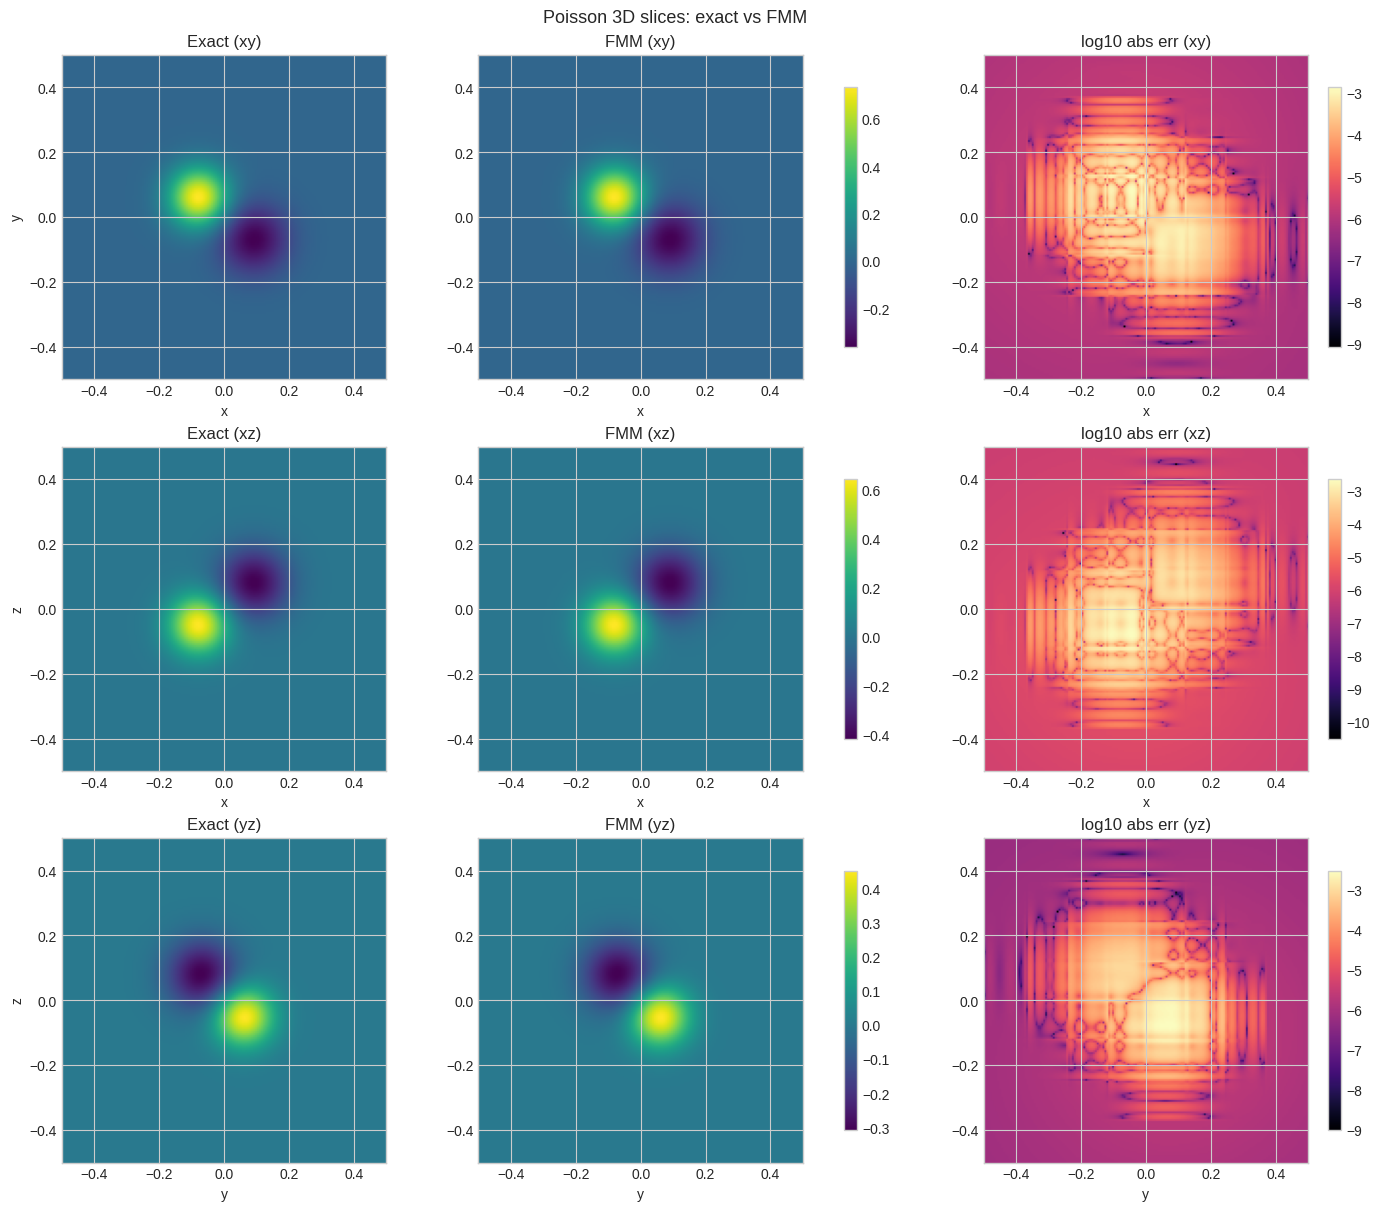

wrote poisson3d_notebook_output/single_error_cloud.png


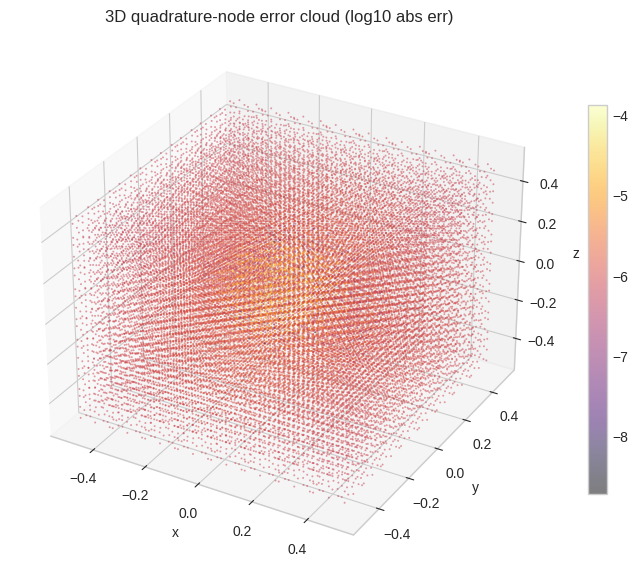

In [5]:
single = run_poisson3d_case(nlevels=default_nlevels, return_fields=True)

for key in ['nlevels', 'n_sources', 'fmm_order', 'elapsed_sec', 'points_per_sec', 'rel_l2_err', 'max_abs_err', 'p99_abs_err']:
    print(f"{key:>14}: {single[key]}")

def _plane_coords(plane_name, line, level=0.0):
    uu, vv = np.meshgrid(line, line, indexing='xy')
    if plane_name == 'xy':
        xx, yy, zz = uu, vv, np.full_like(uu, level)
        plot_u, plot_v = xx, yy
        labels = ('x', 'y')
    elif plane_name == 'xz':
        xx, yy, zz = uu, np.full_like(uu, level), vv
        plot_u, plot_v = xx, zz
        labels = ('x', 'z')
    elif plane_name == 'yz':
        xx, yy, zz = np.full_like(uu, level), uu, vv
        plot_u, plot_v = yy, zz
        labels = ('y', 'z')
    else:
        raise ValueError(plane_name)
    return labels, plot_u, plot_v, xx, yy, zz

line = np.linspace(bbox_a, bbox_b, slice_side)
slices = {}
for plane_name in ('xy', 'xz', 'yz'):
    labels, plot_u, plot_v, xx, yy, zz = _plane_coords(plane_name, line)
    targets = _to_obj_array([xx.ravel(), yy.ravel(), zz.ravel()])
    approx = interpolate_volume_potential(targets, single['trav'], single['wrangler'], single['pot']).get().reshape(xx.shape)
    exact = u_exact(xx, yy, zz)
    slices[plane_name] = {
        'labels': labels,
        'u': plot_u,
        'v': plot_v,
        'exact': exact,
        'approx': approx,
        'abs_err': np.abs(approx - exact),
    }

fig, axes = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)
for irow, plane_name in enumerate(('xy', 'xz', 'yz')):
    data = slices[plane_name]
    uu = data['u']
    vv = data['v']
    exact = data['exact']
    approx = data['approx']
    logerr = np.log10(data['abs_err'] + 1.0e-18)

    extent = (uu.min(), uu.max(), vv.min(), vv.max())
    vmin = min(exact.min(), approx.min())
    vmax = max(exact.max(), approx.max())

    im0 = axes[irow, 0].imshow(exact, origin='lower', extent=extent, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[irow, 1].imshow(approx, origin='lower', extent=extent, cmap='viridis', vmin=vmin, vmax=vmax)
    im2 = axes[irow, 2].imshow(logerr, origin='lower', extent=extent, cmap='magma')

    axes[irow, 0].set_title(f'Exact ({plane_name})')
    axes[irow, 1].set_title(f'FMM ({plane_name})')
    axes[irow, 2].set_title(f'log10 abs err ({plane_name})')

    labels = data['labels']
    for icol in range(3):
        axes[irow, icol].set_xlabel(labels[0])
    axes[irow, 0].set_ylabel(labels[1])

    fig.colorbar(im0, ax=[axes[irow, 0], axes[irow, 1]], shrink=0.8)
    fig.colorbar(im2, ax=axes[irow, 2], shrink=0.8)

fig.suptitle('Poisson 3D slices: exact vs FMM', fontsize=13)
slice_path = artifact_dir / 'single_slices.png'
fig.savefig(slice_path, dpi=220)
print('wrote', slice_path)
plt.show()

max_plot_points = 50000
npts = single['n_sources']
stride = max(1, int(np.ceil(npts / max_plot_points)))
pts = single['source_points_host'][::stride]
err = single['abs_err'][::stride]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    pts[:, 0], pts[:, 1], pts[:, 2],
    c=np.log10(err + 1.0e-18),
    cmap='inferno',
    s=2,
    alpha=0.5,
    linewidths=0,
)
ax.set_title('3D quadrature-node error cloud (log10 abs err)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
fig.colorbar(sc, ax=ax, shrink=0.72)
cloud_path = artifact_dir / 'single_error_cloud.png'
fig.savefig(cloud_path, dpi=220)
print('wrote', cloud_path)
plt.show()


## 5) Uniform Co-Refinement Study

Refine volume resolution (`nlevels`) while keeping the physics fixed.

This reports both accuracy and runtime scaling.


level=3 | sources=8000 | elapsed=1.13s | rel_l2=2.123e-02 | max_abs=1.347e-02


level=4 | sources=64000 | elapsed=2.46s | rel_l2=9.334e-05 | max_abs=1.737e-04


level=5 | sources=512000 | elapsed=5.36s | rel_l2=2.480e-06 | max_abs=2.059e-06


wrote poisson3d_notebook_output/refinement_study.png


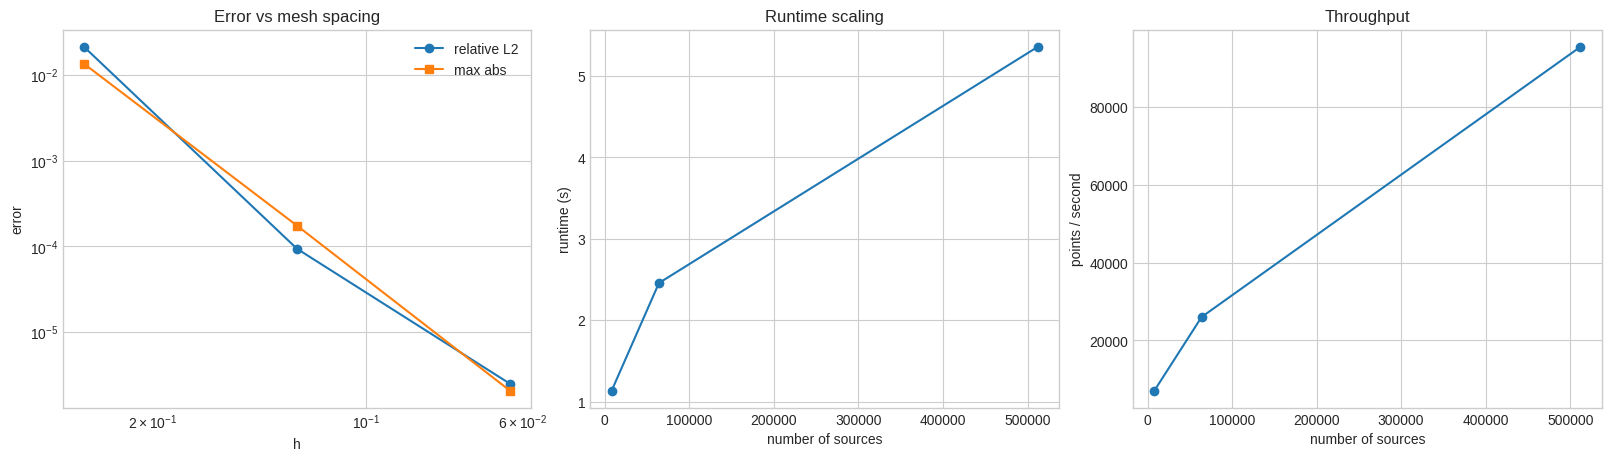

estimated order from rel_l2: 6.531
estimated order from max_abs: 6.338


In [6]:
study_levels = [2, 3] if smoke_mode else [3, 4, 5]
study = []
for lev in study_levels:
    row = run_poisson3d_case(nlevels=lev)
    study.append(row)
    print(
        f"level={row['nlevels']} | sources={row['n_sources']} | elapsed={row['elapsed_sec']:.2f}s | rel_l2={row['rel_l2_err']:.3e} | max_abs={row['max_abs_err']:.3e}"
    )

hs = np.array([row['h'] for row in study])
rel_l2 = np.array([row['rel_l2_err'] for row in study])
max_abs = np.array([row['max_abs_err'] for row in study])
n_sources = np.array([row['n_sources'] for row in study])
elapsed = np.array([row['elapsed_sec'] for row in study])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
axes[0].loglog(hs, rel_l2, 'o-', label='relative L2')
axes[0].loglog(hs, max_abs, 's-', label='max abs')
axes[0].invert_xaxis()
axes[0].set_xlabel('h')
axes[0].set_ylabel('error')
axes[0].set_title('Error vs mesh spacing')
axes[0].legend()

axes[1].plot(n_sources, elapsed, 'o-')
axes[1].set_xlabel('number of sources')
axes[1].set_ylabel('runtime (s)')
axes[1].set_title('Runtime scaling')

axes[2].plot(n_sources, np.array([row['points_per_sec'] for row in study]), 'o-')
axes[2].set_xlabel('number of sources')
axes[2].set_ylabel('points / second')
axes[2].set_title('Throughput')

refine_path = artifact_dir / 'refinement_study.png'
fig.savefig(refine_path, dpi=220)
print('wrote', refine_path)
plt.show()

if len(study) >= 2:
    slope_rel_l2 = np.polyfit(np.log(hs), np.log(rel_l2), 1)[0]
    slope_max_abs = np.polyfit(np.log(hs), np.log(max_abs), 1)[0]
    print(f'estimated order from rel_l2: {slope_rel_l2:.3f}')
    print(f'estimated order from max_abs: {slope_max_abs:.3f}')


## 6) Interactive 3D Isosurfaces

Sample a regular 3D grid and render:

- potential isosurfaces (Viridis),
- error hot-spot isosurfaces (Reds).

If `plotly` is not available, this cell prints a skip message.


In [7]:
vol_line = np.linspace(bbox_a, bbox_b, volume_side)
xx, yy, zz = np.meshgrid(vol_line, vol_line, vol_line, indexing='ij')
targets = _to_obj_array([xx.ravel(), yy.ravel(), zz.ravel()])

approx_vol = interpolate_volume_potential(
    targets, single['trav'], single['wrangler'], single['pot']
).get().reshape(xx.shape)
exact_vol = u_exact(xx, yy, zz)
abs_err = np.abs(approx_vol - exact_vol)

print('volume grid shape:', approx_vol.shape, '| max abs err:', float(abs_err.max()))

volume_npz = artifact_dir / 'volume_samples.npz'
np.savez_compressed(
    volume_npz,
    line=vol_line,
    approx=approx_vol,
    exact=exact_vol,
    abs_err=abs_err,
)
print('wrote', volume_npz)

try:
    import plotly.graph_objects as go

    pot_min = float(np.percentile(approx_vol, 35))
    pot_max = float(np.percentile(approx_vol, 98))
    err_min = float(np.percentile(abs_err, 92))
    err_max = float(np.percentile(abs_err, 99.8))

    fig = go.Figure()
    fig.add_trace(
        go.Isosurface(
            x=xx.ravel(), y=yy.ravel(), z=zz.ravel(),
            value=approx_vol.ravel(),
            isomin=pot_min, isomax=pot_max,
            surface_count=8,
            colorscale='Viridis',
            opacity=0.62,
            caps={'x_show': False, 'y_show': False, 'z_show': False},
            name='Potential',
        )
    )
    fig.add_trace(
        go.Isosurface(
            x=xx.ravel(), y=yy.ravel(), z=zz.ravel(),
            value=abs_err.ravel(),
            isomin=err_min, isomax=err_max,
            surface_count=3,
            colorscale='Reds',
            opacity=0.18,
            showscale=False,
            caps={'x_show': False, 'y_show': False, 'z_show': False},
            name='Error hot spots',
        )
    )

    fig.update_layout(
        title='Poisson 3D: potential + error hot spots',
        template='plotly_white',
        scene={
            'xaxis_title': 'x',
            'yaxis_title': 'y',
            'zaxis_title': 'z',
            'aspectmode': 'cube',
        },
    )
    iso_html = artifact_dir / 'single_isosurface.html'
    fig.write_html(str(iso_html), include_plotlyjs='cdn')
    print('wrote', iso_html)
    fig.show()
except ImportError:
    print('plotly is not installed; skipping interactive isosurface')


volume grid shape: (44, 44, 44) | max abs err: 0.0016327155112243474
wrote poisson3d_notebook_output/volume_samples.npz
plotly is not installed; skipping interactive isosurface


## 7) Takeaways

- 3D volume FMM gives a practical path to Poisson solves with manufactured verification.
- Orthogonal slices are still the fastest sanity-check for 3D fields.
- Point-cloud and isosurface views are useful to locate localized error hot spots.
- For larger production runs, tune `q_order`, `nlevels`, and FMM order jointly based on your error/runtime target.
